# DLAG-SSM (Kalman engine, MOSE kernel)

> **Engine class: SSM-GP** - AR(P) lift of an RBF kernel via `KalmanEMEngine`. The GP prior is approximated by a Markov state-space model. Constant inter-region delay.


Fits `mbrila.DLAG(engine="kalman")` on a synthetic multi-region scenario (5 regions, $K_a=2$ across-region latents, $K_w=1$ within latent per region, $T=200$, heterogeneous per-latent $\sigma\times 10$ and amplitude $\times 3$). The truth uses a **constant** inter-region delay - DLAG's parametric inductive bias.

The notebook produces five figures:

1. **Convergence** - log-likelihood vs iteration
2. **Delay comparison** - fitted vs true $\delta(t)$ per latent, per region pair
3. **Latent comparison** - fitted vs true per-latent traces (trial 0)
4. **PSTH matrix** - trial-averaged neuron-by-time heatmaps (truth | fitted | residual)
5. **Trial-0 reconstruction** - single-trial $y$ overlay for representative neurons

See `examples/demo_dlag_ssm.py` for the equivalent CLI script (identical config).

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch

from mbrila import DLAG, KalmanEMEngine, LatentSpec, MOSEKernel
from mbrila.synthetic.multiregion import MultiRegionScenario

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## Scenario

Same as `demo_dlag_ssm.py` defaults:

* 5 regions x 100 neurons per region
* $K_a=2$ across-region latents (one slow $\sigma=0.05$, one fast $\sigma=0.5$ -> heterogeneous $\sigma\times 10$)
* $K_w=1$ within latent per region
* Constant per-region $\delta$ with amplitudes 3.0 and 1.0 bins (heterogeneous amp $\times 3$)
* SNR = 20, $T=200$, 50 trials

In [2]:
n_trials, T, n_regions = 50, 200, 5
y_dim_per_region, n_across, n_within = 100, 2, 1
sigma_across, sigma_within = 0.05, 0.05
delay_amplitude = 3.0
per_latent_sigma_ratio, per_latent_amp_ratio = 10.0, 3.0

scenario = MultiRegionScenario(
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=n_across,
    n_within=n_within,
    lag_across=2,
    lag_within=2,
    sigma_across=sigma_across,
    sigma_within=sigma_within,
    delay_shape="constant",
    delay_amplitude=delay_amplitude,
    per_latent_amplitudes=tuple(
        delay_amplitude * (1.0 / per_latent_amp_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_shapes=tuple(["constant"] * n_across),
    region_heterogeneity=1.0,
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}"
)

data.y shape = (50, 200, 500)
truth['delay'] shape = (200, 4, 2)
truth['observable'] shape = (50, 200, 15)


## Build & fit model

`KalmanEMEngine.fit()` runs the SSM-GP recipe: a closed-form $(C, d, R)$ refit + initial latent-scale anchor + grouped-AdamW (excludes `beta` / `d_param` from weight decay) + cosine LR + final scale anchor.

In [3]:
spec = LatentSpec(
    n_across=n_across,
    n_within=(n_within,) * n_regions,
)
engine = KalmanEMEngine(
    lr=1e-2,
    lr_min=1e-3,
    weight_decay=1e-2,
    log_every=25,
)
# Init kernel σ at 0.1 - intentionally NOT matching either truth latent's
# σ (slow 0.05, fast 0.5), so the fit has to discover both from data.
init_gamma = 0.1
model = DLAG(
    latent_spec=spec,
    y_dims=scenario.y_dims,
    T=scenario.T,
    kernel_factory_across=lambda: MOSEKernel(num_regions=n_regions, init_sigma=init_gamma),
    kernel_factory_within=lambda: MOSEKernel(num_regions=1, init_sigma=init_gamma),
    engine="kalman",
    engine_override=engine,
    device=device,
    dtype=torch.float64,
).to(device)

# Emission init (data-scaled C, d, R via pCCA).
model.initialize_from_data(data, mode="pcca")

# `model.fit()` runs KalmanEMEngine.fit, which by default does:
#   1. one-shot closed-form (C, d, R) LSE refit
#   2. initial latent-scale anchor
#   3. max_iter grouped-AdamW + cosine LR steps on joint LL
#   4. final scale anchor
# For const-delay models, this recipe converges from a non-truth init
# without an explicit deflation step.
result = model.fit(data, max_iter=300, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[kalman_em] iter 25/300  E_q[log p(x,y)] = 2016743.534


[kalman_em] iter 50/300  E_q[log p(x,y)] = 2039665.948


[kalman_em] iter 75/300  E_q[log p(x,y)] = 2044289.117


[kalman_em] iter 100/300  E_q[log p(x,y)] = 2043838.389


[kalman_em] iter 125/300  E_q[log p(x,y)] = 2043232.263


...

[kalman_em] iter 225/300  E_q[log p(x,y)] = 2041379.092


[kalman_em] iter 250/300  E_q[log p(x,y)] = 2041071.128


[kalman_em] iter 275/300  E_q[log p(x,y)] = 2040840.314


[kalman_em] iter 300/300  E_q[log p(x,y)] = 2040652.410


fit done: 300 iters, wall = 330.4s


## Extract fitted quantities

* `fitted_delay`: $(T, R-1, K_a)$ - for the constant-δ FixedDelay this is broadcast over $T$.
* `fitted_obs`: $(B, T, R \cdot (K_a + K_w))$ - observable latents in the region-major layout.
* `fitted_y`: $(B, T, \sum y_\text{dims})$ - reconstructed observations.
* Apply across-latent permutation alignment (handles latent label-swap symmetry).

In [4]:
fitted_delay = demo.extract_delay(model, scenario.T)
fitted_obs = demo.extract_observable(model, data)
fitted_y = demo.extract_y_recon(model, data)

fitted_obs_aligned, fitted_delay_aligned, perm = nb.align_and_repermute(
    truth["observable"],
    fitted_obs,
    fitted_delay,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
)
delay_rmse = demo.pair_rmse(fitted_delay_aligned, truth["delay"], n_regions)
print(f"across-latent permutation (truth -> fit slot) = {perm}")
print(f"delay_rmse after alignment = {delay_rmse:.4f} bins")

across-latent permutation (truth -> fit slot) = (0, 1)
delay_rmse after alignment = 0.0239 bins


## Figure 1 - Convergence

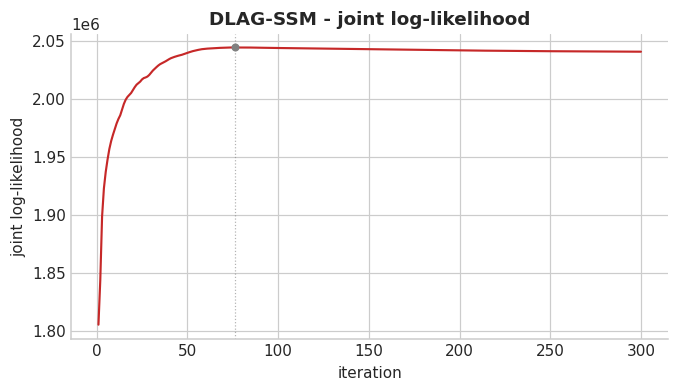

In [5]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="DLAG-SSM - joint log-likelihood")

## Figure 2 - Delay comparison (truth vs fit, per pair)

One panel per `(latent, region pair)` - rows are across-latents, columns are region pairs. Truth dashed, fit solid. Constant truth $\delta$ -> flat dashed lines; fitted should sit on top of truth.

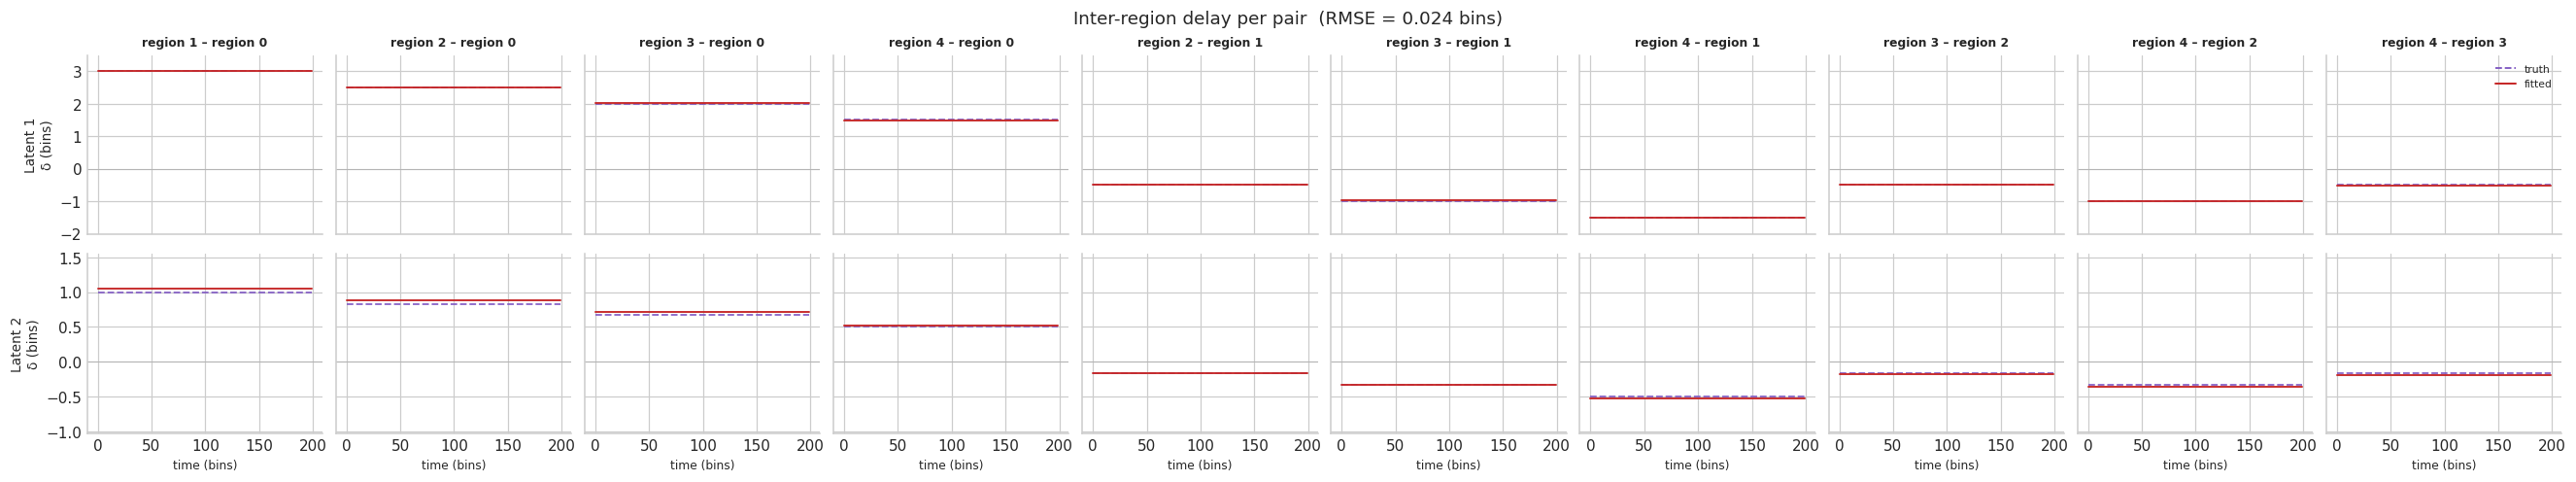

In [6]:
_ = nb.plot_delay_comparison(
    truth["delay"],
    fitted_delay_aligned,
    n_regions=n_regions,
    n_across=n_across,
    rmse=delay_rmse,
)

## Figure 3 - Per-latent traces (trial 0)

One panel per `(latent, region)` - rows are latents (across first, then within), columns are regions. Truth dashed, fit solid; fitted is sign-aligned to truth per panel.

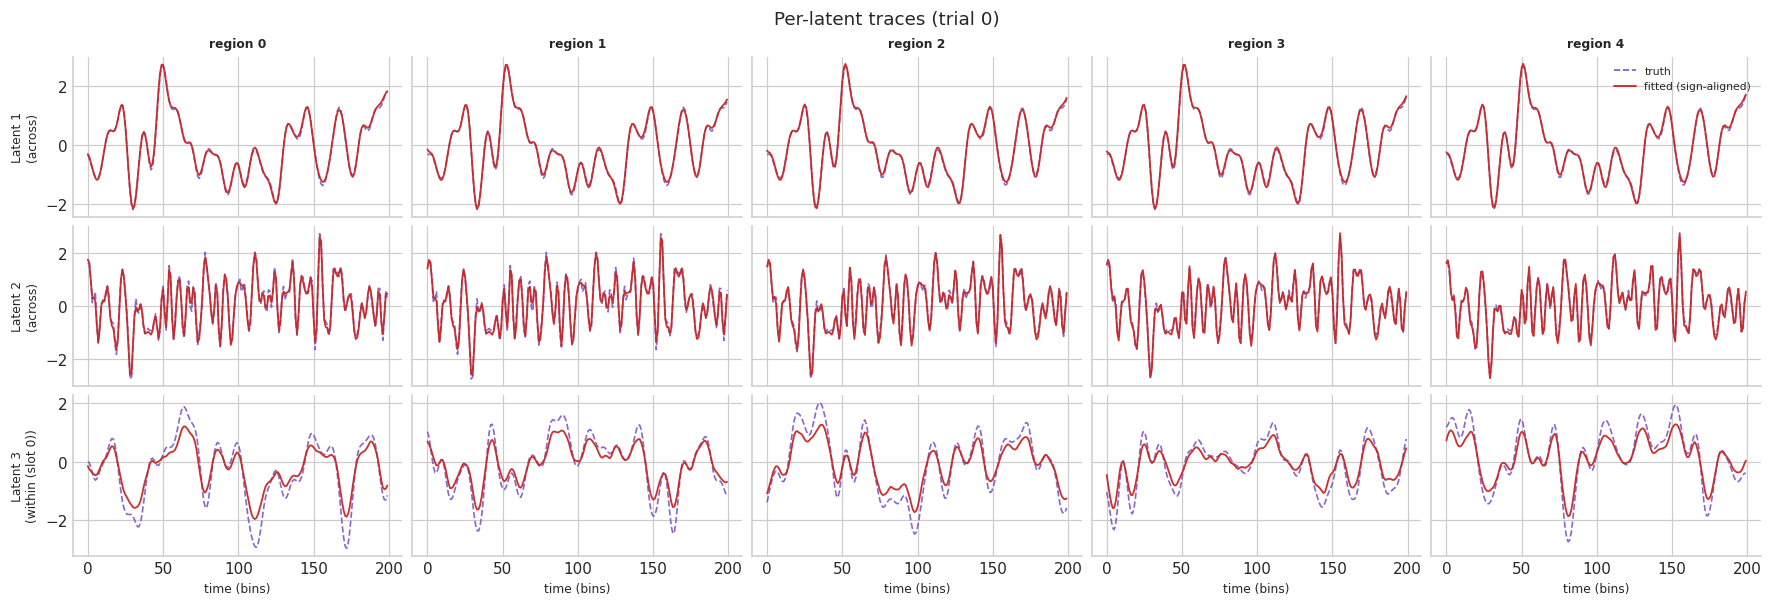

In [7]:
_ = nb.plot_latent_comparison(
    truth["observable"],
    fitted_obs_aligned,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
    trial=0,
)

## Figure 4 - PSTH matrix comparison

Trial-averaged $y$ -> neuron-by-time heatmap. Three panels: truth | fitted | $\text{fitted} - \text{truth}$. Neurons are kept in their natural region-grouped order (horizontal lines mark region boundaries). All three panels use a divergent (`RdBu_r`) colormap centered at 0 - truth and fit share a robust ±99-th-percentile scale, the residual has its own.

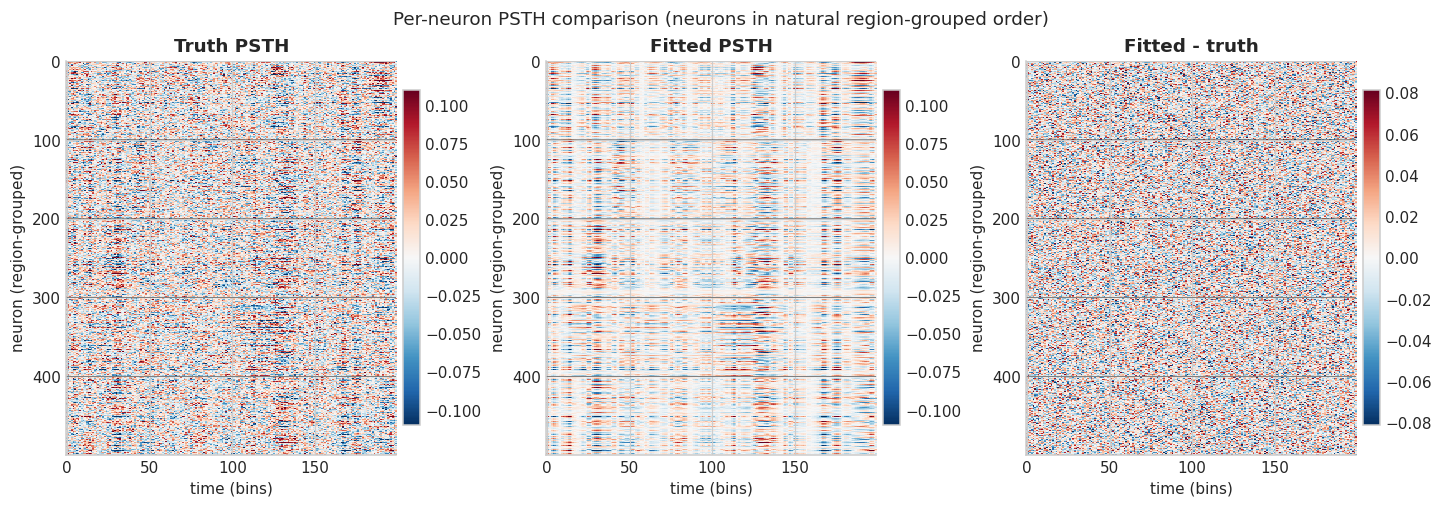

In [8]:
_ = nb.plot_psth_matrix(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
)

## Figure 5 - Trial-0 reconstruction (top-variance neurons per region)

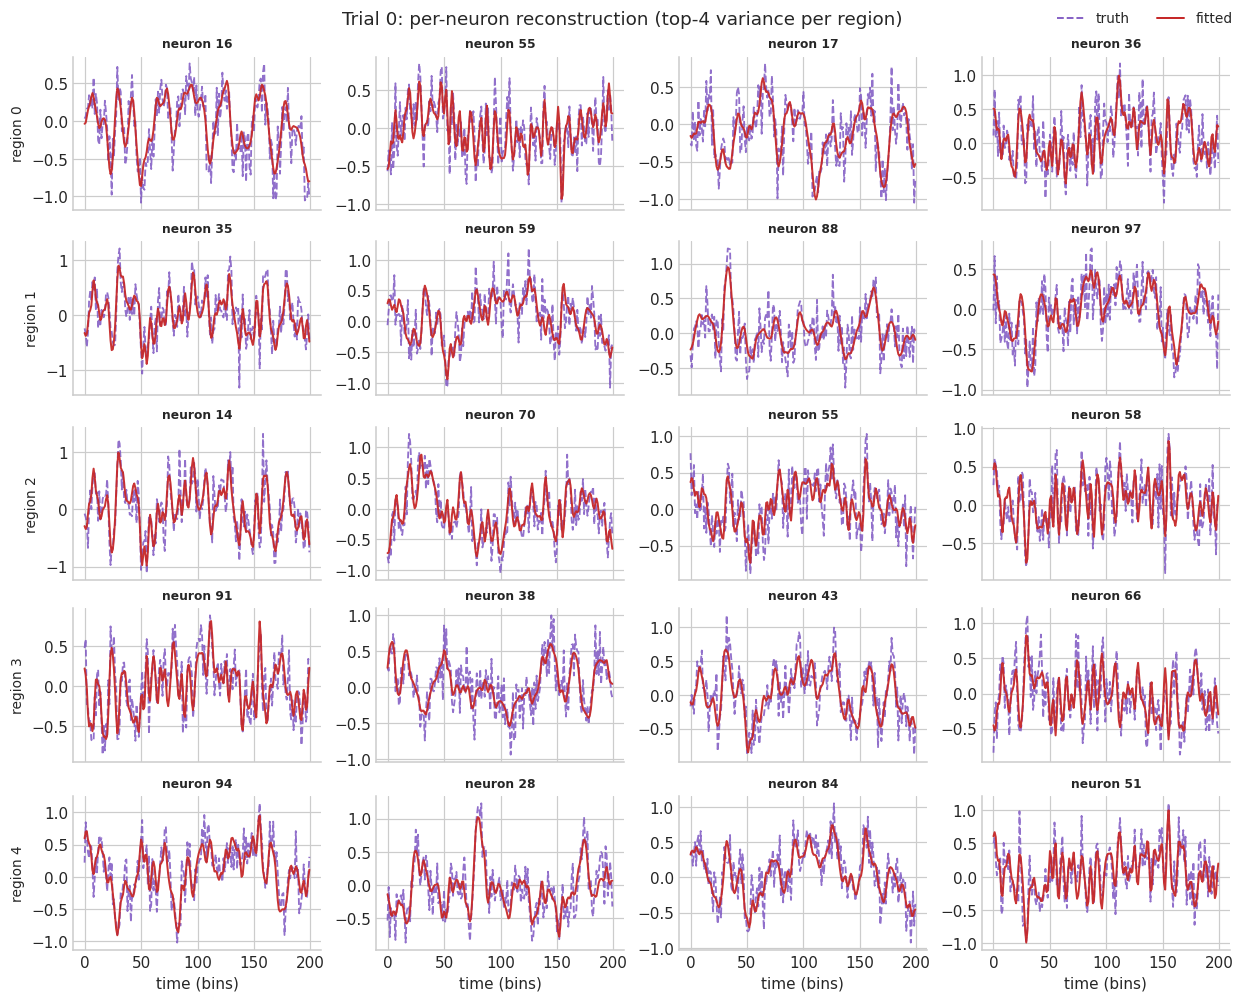

In [9]:
_ = nb.plot_trial0(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
    trial=0,
    n_per_region=4,
)

## Summary

In [10]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"delay_rmse        = {delay_rmse:.4f} bins")
print(f"y_rmse (overall)  = {y_info['overall']:.4f}")
print(f"y_rmse per region = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"across_perm       = {perm}")
print(f"wall time         = {result.wall_time_s:.1f}s")

delay_rmse        = 0.0239 bins
y_rmse (overall)  = 0.2232
y_rmse per region = ['0.2234', '0.2232', '0.2232', '0.2229', '0.2232']
across_perm       = (0, 1)
wall time         = 330.4s
